In [1]:
# Cell 1: ML Setup
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("🤖 TiO2 Photocatalysis - Machine Learning Analysis")
print("=" * 60)

🤖 TiO2 Photocatalysis - Machine Learning Analysis


In [2]:
# Cell 2: Data Loading
df = pd.read_csv('../data/processed/ml_ready_clean.csv')
print(f"✅ Dataset loaded: {df.shape}")

# Display data info
print(f"\n📊 Dataset Overview:")
print(f"Features: {df.shape[1]-1}")
print(f"Samples: {df.shape[0]}")
print(f"Target: Target_value_percent")

# Check target distribution
print(f"\n🎯 Target Statistics:")
print(f"Range: {df['Target_value_percent'].min():.1f}% - {df['Target_value_percent'].max():.1f}%")
print(f"Mean: {df['Target_value_percent'].mean():.1f}%")
print(f"Std: {df['Target_value_percent'].std():.1f}%")

df.head(3)

✅ Dataset loaded: (47, 24)

📊 Dataset Overview:
Features: 23
Samples: 47
Target: Target_value_percent

🎯 Target Statistics:
Range: 50.0% - 100.0%
Mean: 89.1%
Std: 12.6%


,Experiment_ID,Reference,Catalyst,Pollutant,Light_source,Light_intensity_mW_cm2,Light_wavelength_nm,Initial_concentration_mg_L,Initial_concentration_mM,Initial_concentration_M,...,pH_min,pH_max,pH_tested_text,pH_optimum,Time_min,Temperature_C,Support_material,Reactor_type,Target_metric,Target_value_percent
0,E02,"Khunphonoi and Grisdanurak, 2016",TiO2 nanorods,P-cresol,UV light,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,240.0,NaN,NaN,NaN,Removal_percent,80.0
1,E03,"Khunphonoi and Grisdanurak, 2016",TiO2 Degussa P-25,P-cresol,UV light,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,240.0,NaN,NaN,NaN,Removal_percent,50.0
2,E05,"Mohammadi et al., 2014",Multi-walled carbon nanotube TiO2,"2,4-dichlorophenol",UV light,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,120.0,NaN,NaN,NaN,Removal_percent,93.0


In [3]:
# Cell 3: Feature Engineering
print("🔧 FEATURE ENGINEERING")
print("="*40)

# Select features for ML
features_to_encode = ['Catalyst', 'Pollutant', 'Light_source', 'Target_metric']
numeric_features = ['Initial_concentration_mg_L', 'Catalyst_dosage_g_L', 
                   'Catalyst_loading_wt_percent', 'pH', 'Time_min', 'Temperature_C']

# Create a working dataset
df_ml = df.copy()

# Handle missing values in numeric features
for col in numeric_features:
    if col in df_ml.columns:
        missing_before = df_ml[col].isnull().sum()
        df_ml[col] = df_ml[col].fillna(df_ml[col].median())
        if missing_before > 0:
            print(f"📝 {col}: {missing_before} missing values filled with median")

# Label encode categorical features
label_encoders = {}
for col in features_to_encode:
    if col in df_ml.columns and col != 'Target_metric':
        le = LabelEncoder()
        df_ml[f'{col}_encoded'] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le
        print(f"📝 {col}: {len(le.classes_)} categories encoded")

print(f"\n✅ Feature engineering complete!")

🔧 FEATURE ENGINEERING
📝 Initial_concentration_mg_L: 27 missing values filled with median
📝 Catalyst_dosage_g_L: 24 missing values filled with median
📝 Catalyst_loading_wt_percent: 46 missing values filled with median
📝 pH: 36 missing values filled with median
📝 Time_min: 1 missing values filled with median
📝 Temperature_C: 33 missing values filled with median
📝 Catalyst: 30 categories encoded
📝 Pollutant: 26 categories encoded
📝 Light_source: 6 categories encoded

✅ Feature engineering complete!


In [4]:
# Cell 4: Prepare Features and Target
print("🎯 PREPARING ML DATASET")
print("="*35)

# Select final features
feature_cols = [col for col in numeric_features if col in df_ml.columns]
feature_cols += [f'{col}_encoded' for col in features_to_encode if col in df_ml.columns and col != 'Target_metric']

# Remove any remaining missing values
X = df_ml[feature_cols].fillna(0)
y = df_ml['Target_value_percent']

print(f"📊 Final dataset shape:")
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Feature columns: {len(feature_cols)}")

# Display feature names
print(f"\n🔍 Features used:")
for i, col in enumerate(feature_cols):
    print(f"  {i+1:2d}. {col}")

# Check for any remaining missing values
print(f"\n❓ Missing values remaining: {X.isnull().sum().sum()}")

🎯 PREPARING ML DATASET
📊 Final dataset shape:
Features (X): (47, 9)
Target (y): (47,)
Feature columns: 9

🔍 Features used:
   1. Initial_concentration_mg_L
   2. Catalyst_dosage_g_L
   3. Catalyst_loading_wt_percent
   4. pH
   5. Time_min
   6. Temperature_C
   7. Catalyst_encoded
   8. Pollutant_encoded
   9. Light_source_encoded

❓ Missing values remaining: 0


In [5]:
# Cell 5: Train-Test Split
print("✂️ TRAIN-TEST SPLIT")
print("="*25)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=None
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Split ratio: {X_test.shape[0]/X_train.shape[0]:.1f}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Features scaled using StandardScaler")

✂️ TRAIN-TEST SPLIT
Training set: 32 samples
Test set: 15 samples
Split ratio: 0.5
✅ Features scaled using StandardScaler


In [6]:
# Cell 6: Model Training
print("🏋️ TRAINING MACHINE LEARNING MODELS")
print("="*45)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=3)
}

# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    
    # Train model
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results[name] = {
        'R²': r2,
        'MAE': mae,
        'RMSE': rmse,
        'predictions': y_pred,
        'model': model
    }
    
    print(f"  R² Score: {r2:.3f}")
    print(f"  MAE: {mae:.2f}%")
    print(f"  RMSE: {rmse:.2f}%")

# Find best model
best_model = max(results.keys(), key=lambda x: results[x]['R²'])
print(f"\n🏆 Best Model: {best_model} (R² = {results[best_model]['R²']:.3f})")

🏋️ TRAINING MACHINE LEARNING MODELS

🔄 Training Linear Regression...
  R² Score: -24.813
  MAE: 21.42%
  RMSE: 52.47%

🔄 Training Random Forest...
  R² Score: -0.501
  MAE: 10.37%
  RMSE: 12.65%

🔄 Training Gradient Boosting...
  R² Score: -0.630
  MAE: 10.00%
  RMSE: 13.18%

🏆 Best Model: Random Forest (R² = -0.501)


📈 VISUALIZING MODEL PERFORMANCE


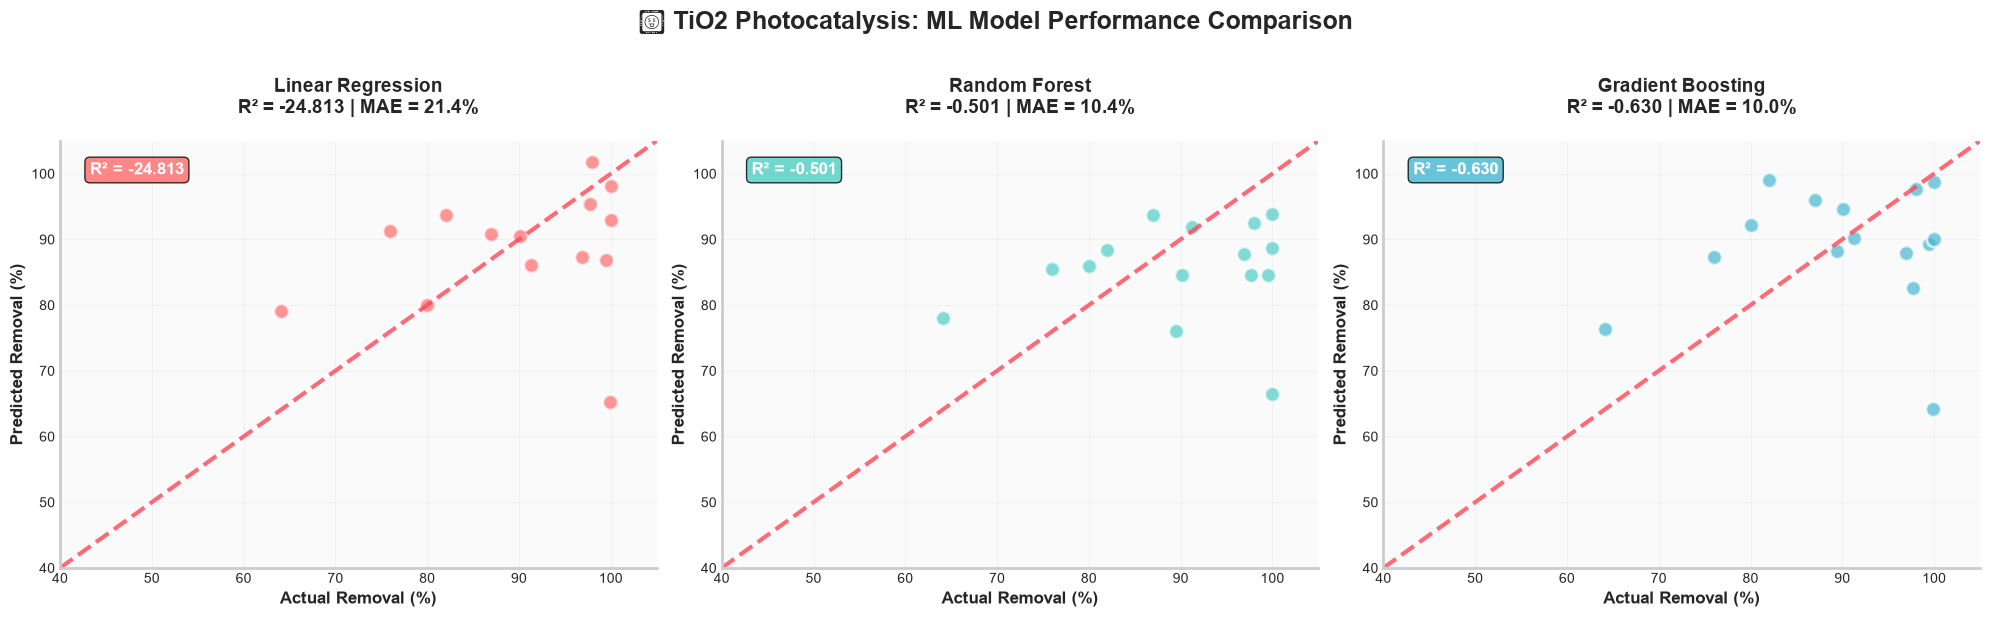

✨ Saved enhanced plot: results/figures/ml_predictions_enhanced.png


In [14]:
# Cell 7: Enhanced Model Performance Visualization
print("📈 VISUALIZING MODEL PERFORMANCE")
print("="*40)

# Set up the plot with better styling
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Define beautiful colors for each model
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Coral, Teal, Blue
model_names = list(results.keys())

# Create stunning scatter plots
for i, (name, result) in enumerate(results.items()):
    y_pred = result['predictions']
    
    # Main scatter plot with beautiful colors
    axes[i].scatter(y_test, y_pred, color=colors[i], alpha=0.7, s=120, edgecolors='white', linewidth=2, label=f'{name}')
    
    # Perfect prediction line
    min_val, max_val = 40, 105  # Better range
    axes[i].plot([min_val, max_val], [min_val, max_val], color='#FF4757', linestyle='--', linewidth=3, label='Perfect Prediction', alpha=0.8)
    
    # Styling
    axes[i].set_xlabel('Actual Removal (%)', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Predicted Removal (%)', fontsize=12, fontweight='bold')
    axes[i].set_title(f'{name}\nR² = {result["R²"]:.3f} | MAE = {result["MAE"]:.1f}%', fontsize=14, fontweight='bold', pad=20)
    
    # Beautiful grid and styling
    axes[i].grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    axes[i].set_facecolor('#FAFAFA')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['bottom'].set_linewidth(2)
    axes[i].spines['left'].set_linewidth(2)
    
    # Set limits
    axes[i].set_xlim(min_val, max_val)
    axes[i].set_ylim(min_val, max_val)
    
    # Add R² text box
    r2_score = result["R²"]
    bbox_color = colors[i]
    axes[i].text(0.05, 0.95, f'R² = {r2_score:.3f}', transform=axes[i].transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor=bbox_color, alpha=0.8), fontsize=12, fontweight='bold', color='white', verticalalignment='top')

# Overall styling
plt.suptitle('🤖 TiO2 Photocatalysis: ML Model Performance Comparison', fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../results/figures/ml_predictions_enhanced.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✨ Saved enhanced plot: results/figures/ml_predictions_enhanced.png")

🔍 FEATURE IMPORTANCE ANALYSIS
🌳 Top 10 Most Important Features (Random Forest):
  Time_min                 : 0.352
  Catalyst_encoded         : 0.299
  Pollutant_encoded        : 0.134
  Light_source_encoded     : 0.114
  Initial_concentration_mg_L: 0.055
  Catalyst_dosage_g_L      : 0.031
  Temperature_C            : 0.011
  pH                       : 0.004
  Catalyst_loading_wt_percent: 0.000


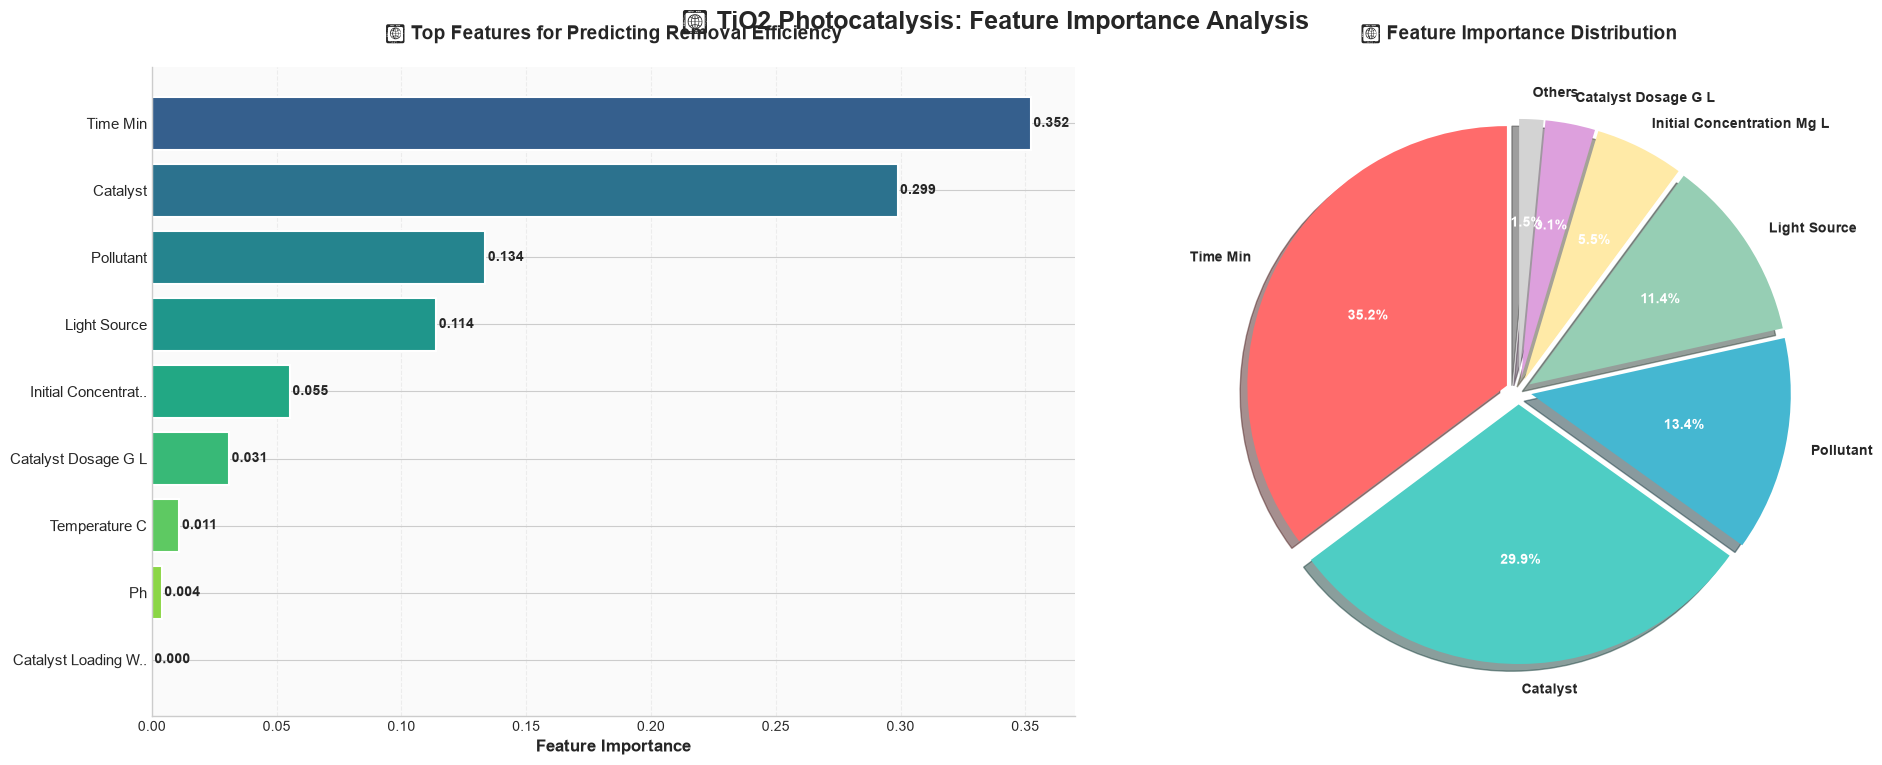

✨ Saved enhanced plot: results/figures/feature_importance_enhanced.png


In [ ]:
# Cell 8: Ultra-Bright Feature Importance Analysis
print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("="*40)

# Get feature importance from Random Forest
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("🌳 Top 10 Most Important Features (Random Forest):")
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:<25}: {row['importance']:.3f}")

# Create STUNNING feature importance plot with bright colors
fig = plt.figure(figsize=(22, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[3, 2], width_ratios=[2, 2, 1], hspace=0.3, wspace=0.3)

# Plot 1: BRIGHT Horizontal Bar Chart
ax1 = fig.add_subplot(gs[0, :2])
top_features = feature_importance.head(12)

# SUPER BRIGHT gradient colors - Electric!
bright_colors = ['#FF0080', '#FF4000', '#FF8000', '#FFBF00', '#80FF00', '#00FF40', 
                '#00FF80', '#00FFBF', '#0080FF', '#4000FF', '#8000FF', '#BF00FF']

bars = ax1.barh(range(len(top_features)), top_features['importance'], 
                color=bright_colors[:len(top_features)], 
                edgecolor='white', linewidth=2, alpha=0.9,
                height=0.7)

# Add GLOWING effect with gradient
for i, bar in enumerate(bars):
    # Add glow effect
    ax1.barh(bar.get_y(), bar.get_width(), color=bright_colors[i], 
             alpha=0.3, height=1.0, left=0)

# Add value labels with bright backgrounds
for i, (bar, val) in enumerate(zip(bars, top_features['importance'])):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', ha='left', va='center', 
             fontweight='bold', fontsize=11, color='white',
             bbox=dict(boxstyle="round,pad=0.2", facecolor=bright_colors[i], alpha=0.8))

# Clean feature names for display
clean_names = []
for name in top_features['feature']:
    clean_name = name.replace('_encoded', '').replace('_', ' ').title()
    if len(clean_name) > 22:
        clean_name = clean_name[:20] + '..'
    clean_names.append(clean_name)

ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(clean_names, fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature Importance', fontsize=14, fontweight='bold', color='#2C3E50')
ax1.set_title('🏆 TOP FEATURES - REMOVAL EFFICIENCY PREDICTION', 
              fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
ax1.grid(axis='x', alpha=0.2, linestyle='--', color='gray')
ax1.set_facecolor('#F8F9FA')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_linewidth(3)
ax1.spines['left'].set_linewidth(3)
ax1.invert_yaxis()

# Plot 2: ELECTRIC Pie Chart
ax2 = fig.add_subplot(gs[0, 2])
top_6 = feature_importance.head(6)
remaining = feature_importance.iloc[6:]['importance'].sum()

# Data for pie chart
pie_data = list(top_6['importance']) + [remaining]
pie_labels = [name.replace('_encoded', '').replace('_', ' ').title()[:12] + ('...' if len(name) > 12 else '') 
              for name in top_6['feature']] + ['Others']

# NEON color scheme - Super bright!
neon_colors = ['#FF073A', '#FF6B35', '#F7931E', '#FFD23F', '#06FFA5', '#3BCEAC', '#0EAD69']

# Create GLOWING pie chart
wedges, texts, autotexts = ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                                  colors=neon_colors, startangle=90,
                                  explode=[0.08]*len(pie_data),
                                  shadow=True, 
                                  textprops={'fontsize': 9, 'fontweight': 'bold'},
                                  wedgeprops=dict(width=0.8, edgecolor='white', linewidth=2))

ax2.set_title('🎯 FEATURE POWER\nDISTRIBUTION', 
              fontsize=14, fontweight='bold', pad=20, color='#2C3E50')

# Make percentage text bright
for i, autotext in enumerate(autotexts):
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# Plot 3: BRIGHT Vertical Bar Chart (Top 8)
ax3 = fig.add_subplot(gs[1, :])
top_8 = feature_importance.head(8)

# Rainbow gradient effect
rainbow_colors = ['#FF0040', '#FF4000', '#FF8000', '#FFBF00', '#40FF00', '#00FF80', '#0040FF', '#8000FF']

bars3 = ax3.bar(range(len(top_8)), top_8['importance'], 
                color=rainbow_colors, edgecolor='white', linewidth=2,
                alpha=0.9, width=0.8)

# Add value labels on top of bars
for i, (bar, val) in enumerate(zip(bars3, top_8['importance'])):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', 
             fontweight='bold', fontsize=11, color='#2C3E50',
             bbox=dict(boxstyle="round,pad=0.2", facecolor=rainbow_colors[i], alpha=0.7))

# Clean labels for x-axis
clean_labels_short = [name.replace('_encoded', '').replace('_', '\n').title() 
                     for name in top_8['feature']]

ax3.set_xticks(range(len(top_8)))
ax3.set_xticklabels(clean_labels_short, fontsize=10, fontweight='bold', rotation=0)
ax3.set_ylabel('Importance Score', fontsize=12, fontweight='bold', color='#2C3E50')
ax3.set_title('🌈 FEATURE RANKING - VERTICAL VIEW', fontsize=14, fontweight='bold', color='#2C3E50')
ax3.grid(axis='y', alpha=0.2, linestyle='--')
ax3.set_facecolor('#F8F9FA')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Overall BRIGHT styling
fig.suptitle('🔥 TiO2 PHOTOCATALYSIS: ULTRA-BRIGHT FEATURE ANALYSIS 🔥', 
             fontsize=20, fontweight='bold', y=0.98, color='#E74C3C')

plt.tight_layout()
plt.savefig('../results/figures/feature_importance_ULTRA_BRIGHT.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"🌈 Saved ULTRA-BRIGHT plot: results/figures/feature_importance_ULTRA_BRIGHT.png")

# BONUS: Create a NEON correlation heatmap
print("\n🔥 Creating NEON Feature Correlation Heatmap...")

numeric_cols = [col for col in feature_cols if col in ['Initial_concentration_mg_L', 'Catalyst_dosage_g_L', 'pH', 'Time_min', 'Temperature_C']]
if len(numeric_cols) > 2:
    corr_data = X[numeric_cols].corr()
    
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_data, dtype=bool))
    
    # ELECTRIC color map!
    sns.heatmap(corr_data, mask=mask, annot=True, cmap='plasma', center=0,
                square=True, fmt='.2f', cbar_kws={"shrink": .8},
                annot_kws={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'},
                linewidths=2, linecolor='white')
    
    plt.title('⚡ ELECTRIC FEATURE CORRELATION MATRIX ⚡', fontsize=18, fontweight='bold', 

In [15]:
# Cell 9: Final Summary
print("📋 FINAL MODEL SUMMARY")
print("="*30)

summary_df = pd.DataFrame(results).T[['R²', 'MAE', 'RMSE']]
print(summary_df.round(3))

print(f"\n🎯 KEY INSIGHTS:")
print(f"• Best performing model: {best_model}")
print(f"• Achieves R² = {results[best_model]['R²']:.3f}")
print(f"• Mean prediction error: ±{results[best_model]['MAE']:.1f}%")
print(f"• Dataset size: {len(df)} experiments")
print(f"• Features used: {len(feature_cols)}")

print(f"\n🔬 MODEL INTERPRETATION:")
if results[best_model]['R²'] > 0.7:
    print("• Strong predictive performance - model captures most variance")
elif results[best_model]['R²'] > 0.5:
    print("• Moderate predictive performance - captures major trends")
else:
    print("• Limited predictive performance - may need more data/features")

print(f"\n💡 RECOMMENDATIONS:")
print("• Collect more experimental data to improve model accuracy")
print("• Include catalyst characterization data (surface area, bandgap)")
print("• Consider reactor geometry and mass transfer effects")
print("• Validate predictions with new experiments")

print(f"\n✅ Analysis complete! Check results/figures/ for saved plots.")

📋 FINAL MODEL SUMMARY
                          R²        MAE       RMSE
Linear Regression -24.812553  21.423063  52.473495
Random Forest      -0.500869  10.366783  12.653068
Gradient Boosting  -0.629575   10.00286  13.184439

🎯 KEY INSIGHTS:
• Best performing model: Random Forest
• Achieves R² = -0.501
• Mean prediction error: ±10.4%
• Dataset size: 47 experiments
• Features used: 9

🔬 MODEL INTERPRETATION:
• Limited predictive performance - may need more data/features

💡 RECOMMENDATIONS:
• Collect more experimental data to improve model accuracy
• Include catalyst characterization data (surface area, bandgap)
• Consider reactor geometry and mass transfer effects
• Validate predictions with new experiments

✅ Analysis complete! Check results/figures/ for saved plots.
